In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [49]:
df = pd.read_csv("Data/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [51]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [52]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [53]:
cat_cols = df.select_dtypes(include="object").columns
print(cat_cols)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [54]:
for i in cat_cols:
    print(df[i].value_counts())

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
default
no     44396
yes      815
Name: count, dtype: int64
housing
yes    25130
no     20081
Name: count, dtype: int64
loan
no     37967
yes     7244
Name: count, dtype: int64
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64
poutcome
unknown    36959
failure     4901
other  

In [55]:
print(df["y"].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


This suggest class imbalance. Class imbalance is the most critical hurdle in the Bank Marketing dataset. Since only about 11–12% of customers actually subscribe (the "Yes" class), a standard model will default to predicting "No" for everyone to achieve high accuracy.


1. The Algorithmic Approach (Class Weights)
This is the easiest and most "mathematical" way. Instead of changing the data, you tell the model to "pay more attention" to the minority class by penalizing errors on "Yes" more heavily than errors on "No."

In scikit-learn, we perform this by using class_weight='balanced' hyperparamter.

2. The Data Approach: SMOTE (Oversampling)
SMOTE (Synthetic Minority Over-sampling Technique) is a favorite for Master's level projects. Instead of just duplicating the "Yes" rows, it looks at the "K-nearest neighbors" of a "Yes" instance and creates new, synthetic data points between them.

Important: You must only apply SMOTE to your training data, never the test data.

3. The Evaluation Approach (The Threshold Shift)
By default, models use a probability threshold of 0.5. For imbalanced data, this is often too high. You can lower the threshold to catch more "Yes" cases.

In [56]:
X = df.drop('y', axis=1)
Y = df['y']


In [57]:
cat_cols = X.select_dtypes(include="object").columns
encoded_X = pd.get_dummies(X, columns=cat_cols)

In [58]:
X_train, X_test, Y_train, Y_test = train_test_split(encoded_X, Y, test_size=0.2, random_state=42)

In [59]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_res, Y_train_res = sm.fit_resample(X_train, Y_train)

print(pd.Series(Y_train_res).value_counts())

y
no     31970
yes    31970
Name: count, dtype: int64


In [60]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_res, Y_train_res)
dt_preds = dt_model.predict(X_test)

In [61]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_res, Y_train_res)
rf_preds = rf_model.predict(X_test)

--- Decision Tree ---
Accuracy: 0.87
Confusion Matrix:


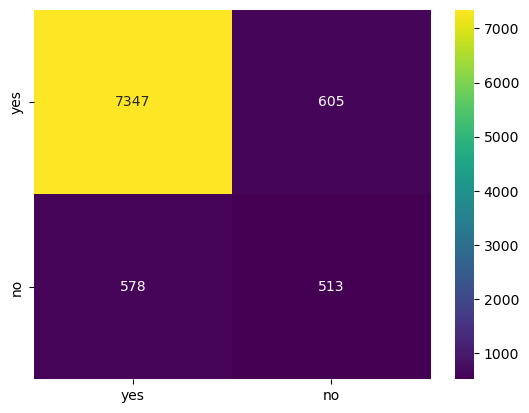


Classification Report:
              precision    recall  f1-score   support

          no       0.93      0.92      0.93      7952
         yes       0.46      0.47      0.46      1091

    accuracy                           0.87      9043
   macro avg       0.69      0.70      0.69      9043
weighted avg       0.87      0.87      0.87      9043

------------------------------
--- Random Forest (Balanced) ---
Accuracy: 0.90
Confusion Matrix:


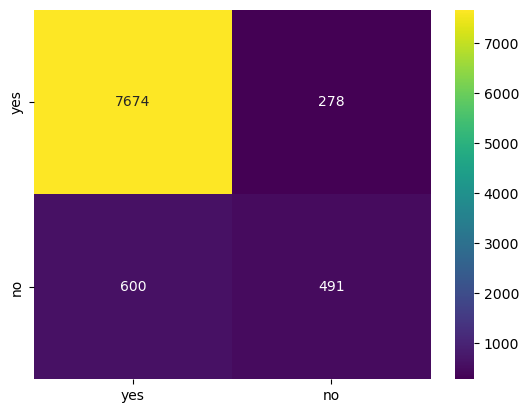


Classification Report:
              precision    recall  f1-score   support

          no       0.93      0.97      0.95      7952
         yes       0.64      0.45      0.53      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.71      0.74      9043
weighted avg       0.89      0.90      0.90      9043

------------------------------


In [62]:
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.2f}")
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=["yes", "no"], yticklabels=["yes", "no"])
    plt.show()
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("-" * 30)

evaluate_model("Decision Tree", Y_test, dt_preds)
evaluate_model("Random Forest (Balanced)", Y_test, rf_preds)

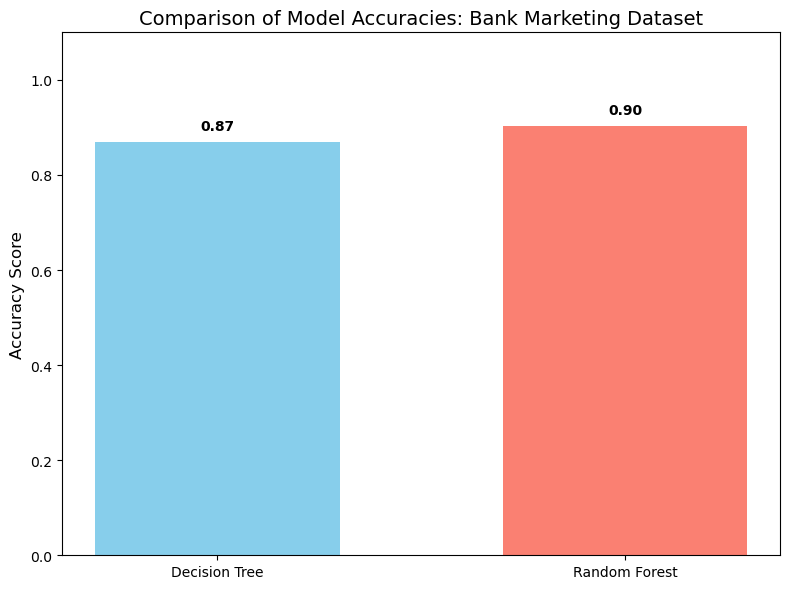

In [63]:
model_names = ['Decision Tree', 'Random Forest']
accuracy_scores = [accuracy_score(Y_test, dt_preds), accuracy_score(Y_test, rf_preds)]  

plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, accuracy_scores, color=['skyblue', 'salmon'], width=0.6)

plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Comparison of Model Accuracies: Bank Marketing Dataset', fontsize=14)
plt.ylim(0, 1.1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()